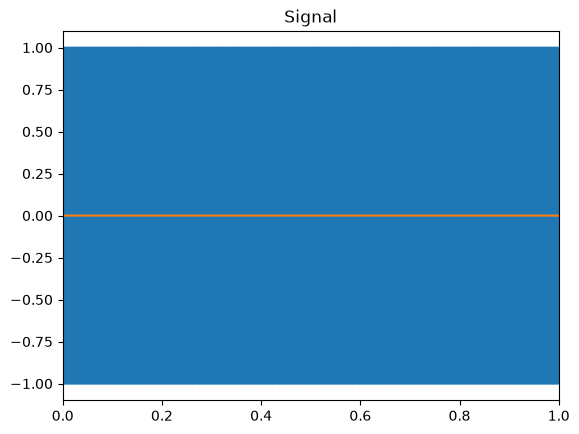

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

#note pour plus tard: @np.vectorize

from IPython.display import Audio
from IPython.display import display
from scipy.io import wavfile
from scipy import integrate

RATE = 44_100
LA = 440
DO = 523.25

# SYNTHETISEUR - FREQUENCE

#1. Le tableau doit contenir 44100 échantillons.

#2. Position=np.sin(t*phi*2*np.pi) avec t le temps et phi la fréquence

#3.

T=np.linspace(0,1,RATE) #changer le 1 en 0.050 pour afficher 50 ms.
phi=LA
Position=np.sin(T*phi*2*np.pi)

plt.plot(T,Position)
#plt.show()

#display(Audio(Position,rate=RATE))

#4.
def display_signal(signal, rate=RATE, title="Signal", width=1):
    display(Audio(data=signal,rate=rate))
    duration=len(signal)*rate #la durée en temps du signal
    T=np.linspace(0,duration,len(signal)) #les abscisses vont de 0 à la durée du signal, avec len(signal) points
    plt.plot(T,signal)
    plt.xlim(0,width) #on borne l'affichage d'abscisses à width choisi
    plt.title(title)
    plt.show() #et on affiche

#display_signal(Position, RATE, "Signal", 0.050)


#2.2

def sine(freq,duration=1,amplitude=1.):
    Abscisses=np.linspace(0,duration,int(RATE*duration))
    SignalProduit=(np.sin(2*np.pi*freq*Abscisses))*amplitude
    return SignalProduit



#display_signal(sine(440))



#2.3

def sine_linear(freq1,freq2,duration):
    FreqDeT=np.linspace(freq1,freq2,1000) #On choisit de passer par 1000 valeurs de fréquence différentes
    T=np.linspace(0,duration,int(RATE*duration))
    PhiDeT=2*np.pi*np.vectorize(integrate(0,T,FreqDeT))
    SignalProduit=np.sin(PhiDeT)
    return SignalProduit
# Complexité trop grande: ce code impose de calculer une intégrale à chaque point calculé de PhiDeT 
#display_signal(sine_linear(400,4000,1),width=0.050)


#3.

#3.1

#Méthode proposée: Créer un tableau Volume(t), un tableau SignalBase(t), les combiner en 1 tableau de 2 valeurs par case, et utiliser la fonction d'agrégation produit sur les cases

#3.2 et 3.3

def crescendo_sine(freq,duration,vol1,vol2,increase=True):
    
    T=np.linspace(0,duration,int(RATE*duration))
    SinusDeT=sine(freq,duration,vol1)
    VolumeDeT=np.linspace(vol1,vol2,len(SinusDeT))
    if increase==False: #on renverse VolumeDeT
        VolumeDeT=VolumeDeT[::-1]
    
    SignalRes=np.multiply(SinusDeT,VolumeDeT)
    #plt.plot(T, SignalRes)
    #plt.xlim(0,0.3)
    #plt.show()
    return SignalRes

#display_signal(crescendo_sine(440,10,1,10,True))
# Erreur que je ne comprends pas: SignalRes semble avoir les bonnes valeurs, c'est à l'affichage que le signal apparaît de volume constant ...

#3.4 Cette approche s'applique à n'importe quel son.

#4.

def suiteLaDo():
    SecondeDeLa=sine(LA,1,1)
    SecondeDeDo=sine(DO,1,1)
    SignalConc=np.concatenate((SecondeDeLa,SecondeDeDo),axis=0)
    return SignalConc

#display_signal(suiteLaDo())

#5.

#5.3

def float_to_int16(as_float):
    Res=(as_float*32767).astype('int16')
    return Res


#6.

IndexNote=np.arange(0,13)
IndexNote=IndexNote/12
ratios=np.exp2(IndexNote) #on prend la puissance 2
#print(ratios)

def freq_from_name(name):
    Frequences=ratios*440
    Noms=['la','la#','si','do','do#','ré','ré#','mi','fa','fa#','sol','sol#','laprim']
    Notes={}
    for i in range(len(Frequences)):
        Notes[Noms[i]]=Frequences[i]
    return Notes[name]

#print(freq_from_name('do#'))

#7. Il faut ajouter les trois sinusoïdes correspondantes

def Accord(fondamental,majeur=True):
    #Sélection des fréquences à jouer:
    #Le fondamental et la quinte sont toujours jouées
    FreqAJouer=np.empty(3)
    FreqAJouer[0]=freq_from_name(fondamental)
    FreqAJouer[2]=FreqAJouer[0]*(2**(7/12)) #Quinte ajoutée
    if majeur==True:
        FreqAJouer[1]=FreqAJouer[0]*(2**(4/12)) #Tierce majeure ajoutée
    else:
        FreqAJouer[1]=FreqAJouer[0]*(2**(3/12)) #Tierce mineure ajoutée
    SignalFondamental=sine(FreqAJouer[0])
    SignalTierce=sine(FreqAJouer[1])
    SignalQuinte=sine(FreqAJouer[2])
    SignalFinal=np.empty((len(SignalFondamental),3))
    SignalFinal=SignalFondamental+SignalTierce+SignalQuinte
    return SignalFinal/3 #on fait la moyenne plutôt que la somme pour ne pas augmenter le volume

#display_signal(Accord('la',True)) #on a bien un la majeur pendant 1 seconde



#FINIR JUSQU'A Q11.
#Q11.2 il faut faire attention, il y a une histoire de astype
#La fréquence des violons dépasse 30 000, donc il faut passer en int.32 temporairement pour le calcul.

